In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import LabelEncoder

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Shape:", df.shape)
print(df.head())

Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [2]:
print(df.describe())
print("\nMissing values:", df.isnull().sum().sum())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [3]:
# Rooms per household
df["RoomsPerHousehold"] = df["AveRooms"] / df["HouseAge"]

# Bedrooms ratio
df["BedroomRatio"] = df["AveBedrms"] / df["AveRooms"]

# Population per household
df["PopulationPerHousehold"] = df["Population"] / df["AveOccup"]

print("New features added!")
print(df[["RoomsPerHousehold", "BedroomRatio", "PopulationPerHousehold"]].head())

New features added!
   RoomsPerHousehold  BedroomRatio  PopulationPerHousehold
0           0.170345      0.146591                   126.0
1           0.297054      0.155797                  1138.0
2           0.159387      0.129516                   177.0
3           0.111872      0.184458                   219.0
4           0.120805      0.172096                   259.0


In [4]:
# Income groups banao (Label Encoding ke liye)
df["IncomeGroup"] = pd.cut(df["MedInc"],
                            bins=[0, 2, 4, 6, 100],
                            labels=["Low", "Medium", "High", "Very High"])

# Label Encoding
le = LabelEncoder()
df["IncomeGroup_Label"] = le.fit_transform(df["IncomeGroup"])

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["IncomeGroup"], prefix="Income")

print("Encoding complete!")
print(df_encoded.head())

Encoding complete!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  RoomsPerHousehold  BedroomRatio  PopulationPerHousehold  \
0    -122.23  4.526           0.170345      0.146591                   126.0   
1    -122.22  3.585           0.297054      0.155797                  1138.0   
2    -122.24  3.521           0.159387      0.129516                   177.0   
3    -122.25  3.413           0.111872      0.184458                   219.0   
4    -122.25  3.422           0.120805      0.172096                   259.0   

   IncomeGroup_Label  Income_Low  Income_Me

In [5]:
# Pehle skewness dekho
print("Before log transform:")
print(f"  Population skewness: {df['Population'].skew():.2f}")
print(f"  Price skewness: {df['Price'].skew():.2f}")

# Log transform apply karo
df_encoded["Population_log"] = np.log1p(df_encoded["Population"])
df_encoded["Price_log"] = np.log1p(df_encoded["Price"])

print("\nAfter log transform:")
print(f"  Population_log skewness: {df_encoded['Population_log'].skew():.2f}")
print(f"  Price_log skewness: {df_encoded['Price_log'].skew():.2f}")

Before log transform:
  Population skewness: 4.94
  Price skewness: 0.98

After log transform:
  Population_log skewness: -1.04
  Price_log skewness: 0.28


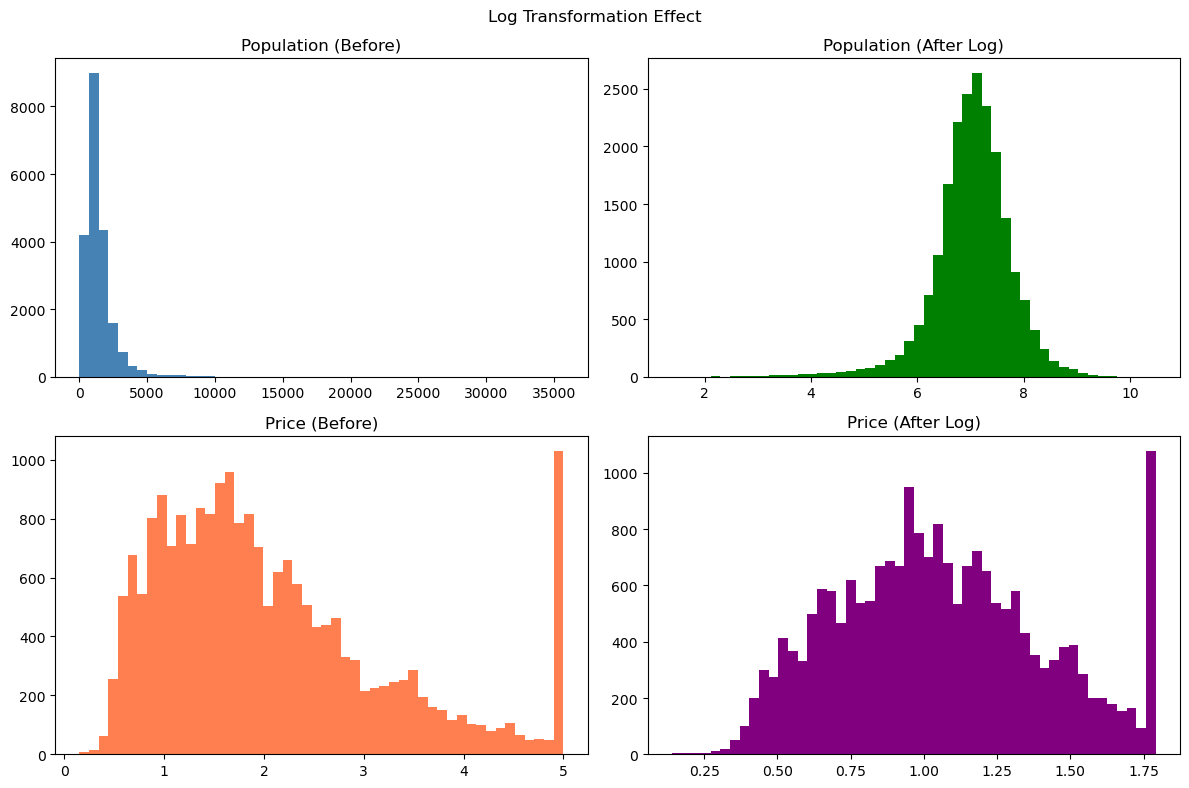

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0][0].hist(df["Population"], bins=50, color="steelblue")
axes[0][0].set_title("Population (Before)")

axes[0][1].hist(df_encoded["Population_log"], bins=50, color="green")
axes[0][1].set_title("Population (After Log)")

axes[1][0].hist(df["Price"], bins=50, color="coral")
axes[1][0].set_title("Price (Before)")

axes[1][1].hist(df_encoded["Price_log"], bins=50, color="purple")
axes[1][1].set_title("Price (After Log)")

plt.suptitle("Log Transformation Effect")
plt.tight_layout()
plt.savefig("log_transform.png")
plt.show()

In [7]:
df_encoded.to_csv("enhanced_dataset.csv", index=False)
print("Enhanced dataset saved!")
print("Final shape:", df_encoded.shape)

Enhanced dataset saved!
Final shape: (20640, 19)
